[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mansamoussa/zebrAssist/blob/master/notebooks/2_SWIN_TrafficLight_Classifier.ipynb)

# SWIN Classifier — Pedestrian Traffic Lights (Red / Yellow / Green)

This notebook fine-tunes a **Swin Transformer** image classifier on **cropped traffic light images**.
It works both on **Colab** and **local Jupyter**.

In [1]:
# Install dependencies (safe on Colab; on local this is no-op if already installed)
try:
    import google.colab  # noqa
    IN_COLAB = True
except Exception:
    IN_COLAB = False

print("Running on Colab:", IN_COLAB)

# timm for pretrained SWIN; torchmetrics optional
!pip -q install --upgrade timm torchmetrics

Running on Colab: False


In [3]:
# Imports
import os, sys, math, time, json, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from torchmetrics.classification import MulticlassAccuracy, MulticlassPrecision, MulticlassRecall, MulticlassF1Score, MulticlassConfusionMatrix
import matplotlib.pyplot as plt


In [ ]:
# Detect device
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

# Reproducibility
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(42)

# ---- USER VARIABLES ----
DATA_ROOT = Path("/content/data/cropped_images" if 'IN_COLAB' in globals() and IN_COLAB else "../data/cropped_images")
CLASS_NAMES = ["red", "yellow", "green"]   # folder names under train/val/test
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 25
LR = 5e-4
WEIGHT_DECAY = 1e-4
MODEL_NAME = "swin_tiny_patch4_window7_224"   # or 'swin_base_patch4_window7_224' if we have more GPU
RUNS_DIR = Path("./runs_swin")
RUN_NAME = "swin_tl_rgb"
RUN_DIR = RUNS_DIR / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)
print("DATA_ROOT:", DATA_ROOT.resolve())

Device: mps
DATA_ROOT: /Users/mothiam/Documents/Mouha Perso/HSLU/Semester3/Computer_vision/Project/zebrAssist/data/cropped_images


In [6]:
# Transforms
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=10, translate=(0.1,0.1), scale=(0.9,1.1)),
    transforms.ColorJitter(hue=0.02, saturation=0.4, brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

In [7]:

# ImageFolder expects folder/class structure
train_dir = DATA_ROOT / "train"
val_dir   = DATA_ROOT / "val"

if not train_dir.exists() or not val_dir.exists():
    raise FileNotFoundError(f"Expected train/ and val/ under {DATA_ROOT}. See the first cell for layout.")

train_ds = datasets.ImageFolder(str(train_dir), transform=train_tfms)
val_ds   = datasets.ImageFolder(str(val_dir),   transform=val_tfms)

# Check class-to-index mapping
print("Class-to-index mapping:", train_ds.class_to_idx)

# Optional: class weights for imbalance
counts = [0]*len(train_ds.classes)
for _, y in train_ds.samples:
    counts[y] += 1
class_weights = torch.tensor([max(counts)/c for c in counts], dtype=torch.float32, device=device)

# Loaders
num_workers = 2 if (not IN_COLAB) else 2
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=True)

print(f"Train images: {len(train_ds)} | Val images: {len(val_ds)}")

Class-to-index mapping: {'green': 0, 'red': 1, 'yellow': 2}
Train images: 43 | Val images: 10


/Users/mothiam/Documents/Mouha Perso/HSLU/Semester3/Computer_vision/Project/zebrAssist/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


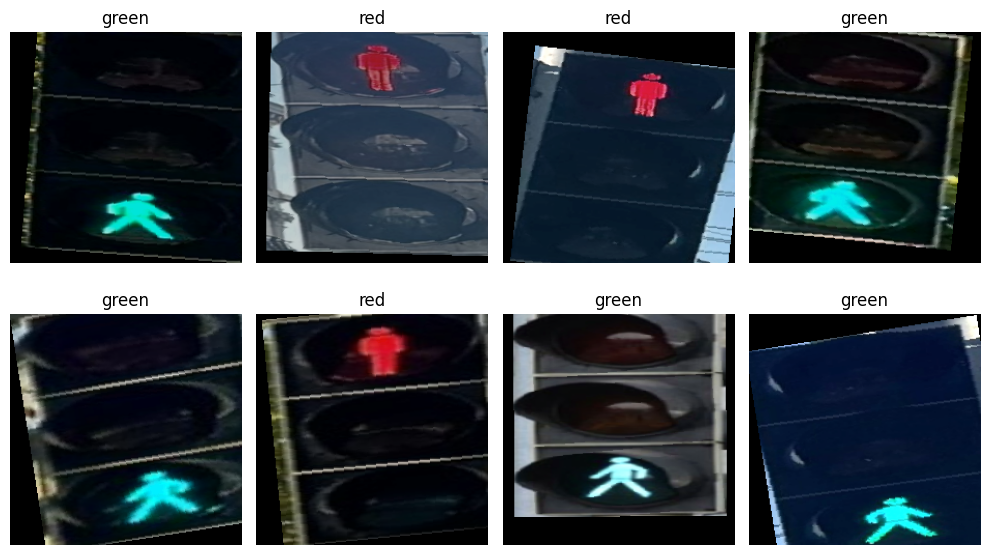

In [8]:
# Quick sanity check: visualize a batch
%matplotlib inline
batch = next(iter(train_loader))
imgs, labels = batch
grid = imgs[:8]

fig = plt.figure(figsize=(10, 6))
for i in range(len(grid)):
    plt.subplot(2, 4, i+1)
    # unnormalize
    img = grid[i].permute(1,2,0).cpu().numpy()
    img = img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(train_ds.classes[labels[i].item()])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [9]:
# Create SWIN model
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=len(train_ds.classes))
model.to(device)

# Loss — use Weighted CrossEntropy if classes are imbalanced
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer & Scheduler
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# AMP scaler
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

/var/folders/zv/3c7v85ts3l7fnz1x1vrtpn3h0000gn/T/ipykernel_84807/1107786614.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


In [ ]:
def train_one_epoch(epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

@torch.no_grad()
def evaluate(loader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    # Metrics
    accm = MulticlassAccuracy(num_classes=len(train_ds.classes)).to(device)
    precm = MulticlassPrecision(num_classes=len(train_ds.classes), average='macro').to(device)
    recallm = MulticlassRecall(num_classes=len(train_ds.classes), average='macro').to(device)
    f1m = MulticlassF1Score(num_classes=len(train_ds.classes), average='macro').to(device)

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

        accm.update(preds, labels)
        precm.update(preds, labels)
        recallm.update(preds, labels)
        f1m.update(preds, labels)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    metrics = {
        "acc": accm.compute().item(),
        "precision_macro": precm.compute().item(),
        "recall_macro": recallm.compute().item(),
        "f1_macro": f1m.compute().item(),
    }
    return epoch_loss, epoch_acc, metrics

best_val_acc = 0.0
patience = 7
bad_epochs = 0
history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}

for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(epoch)
    val_loss, val_acc, metrics = evaluate(val_loader)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"Val loss {val_loss:.4f} acc {val_acc:.4f} | "
          f"Val f1(macro) {metrics['f1_macro']:.4f} | "
          f"time {(time.time()-t0):.1f}s")

    # Save best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({"model": model.state_dict(),
                    "classes": train_ds.classes,
                    "model_name": MODEL_NAME,
                    "img_size": IMG_SIZE},
                   RUN_DIR / "best_swin.pth")
        bad_epochs = 0
    else:
        bad_epochs += 1

    if bad_epochs >= patience:
        print(f"Early stopping at epoch {epoch} (no val acc improvement in {patience} epochs).")
        break

print("Best val acc:", best_val_acc)

/var/folders/zv/3c7v85ts3l7fnz1x1vrtpn3h0000gn/T/ipykernel_84807/1877005434.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 01/25 | Train loss 1.2381 acc 0.4186 | Val loss 1.2960 acc 0.2000 | Val f1(macro) 0.1111 | time 31.1s
Epoch 02/25 | Train loss 1.2257 acc 0.3023 | Val loss 0.8828 acc 0.6000 | Val f1(macro) 0.6127 | time 19.2s
Epoch 03/25 | Train loss 0.6186 acc 0.9302 | Val loss 0.1187 acc 1.0000 | Val f1(macro) 1.0000 | time 19.0s
Epoch 04/25 | Train loss 0.0830 acc 1.0000 | Val loss 0.0015 acc 1.0000 | Val f1(macro) 1.0000 | time 18.8s
Epoch 05/25 | Train loss 0.0029 acc 1.0000 | Val loss 0.0001 acc 1.0000 | Val f1(macro) 1.0000 | time 19.1s
Epoch 06/25 | Train loss 0.0024 acc 1.0000 | Val loss 0.0000 acc 1.0000 | Val f1(macro) 1.0000 | time 18.9s
Epoch 07/25 | Train loss 0.0003 acc 1.0000 | Val loss 0.0000 acc 1.0000 | Val f1(macro) 1.0000 | time 18.9s
Epoch 08/25 | Train loss 0.6238 acc 0.8837 | Val loss 0.0000 acc 1.0000 | Val f1(macro) 1.0000 | time 18.9s
Epoch 09/25 | Train loss 0.2880 acc 0.9535 | Val loss 0.0775 acc 1.0000 | Val f1(macro) 1.0000 | time 18.9s
Epoch 10/25 | Train loss 0.3

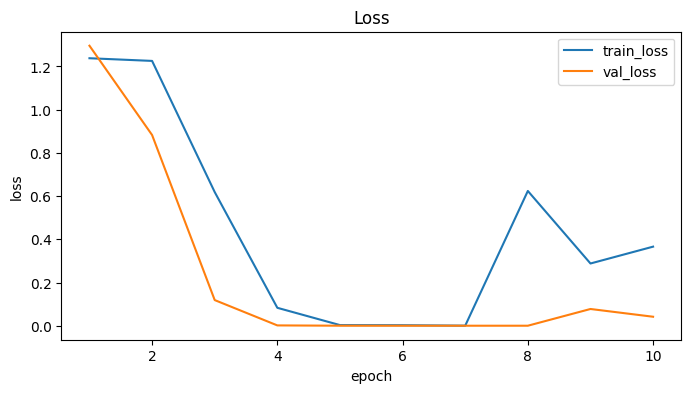

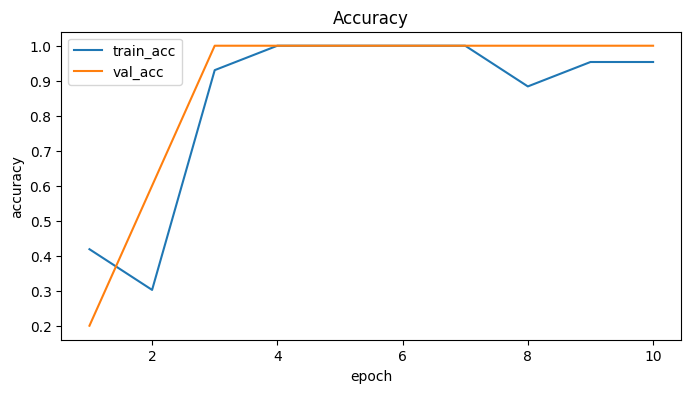

In [11]:
# Plot training curves
epochs_ran = len(history["train_loss"])
plt.figure(figsize=(8,4))
plt.plot(range(1, epochs_ran+1), history["train_loss"], label="train_loss")
plt.plot(range(1, epochs_ran+1), history["val_loss"], label="val_loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Loss"); plt.show()

plt.figure(figsize=(8,4))
plt.plot(range(1, epochs_ran+1), history["train_acc"], label="train_acc")
plt.plot(range(1, epochs_ran+1), history["val_acc"], label="val_acc")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.title("Accuracy"); plt.show()

Confusion matrix (rows=true, cols=pred):
 [[3 0 0]
 [0 5 0]
 [0 0 2]]


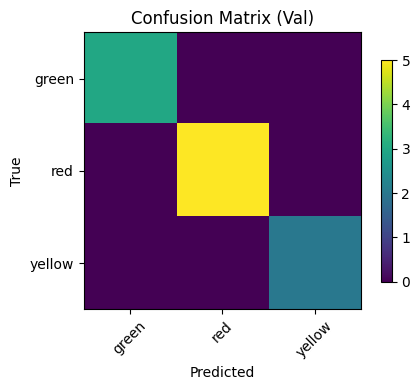

In [12]:
# Confusion matrix on validation set
@torch.no_grad()
def confusion_matrix(loader):
    model.eval()
    cm_metric = MulticlassConfusionMatrix(num_classes=len(train_ds.classes)).to(device)
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)
        cm_metric.update(preds, labels)
    return cm_metric.compute().cpu().numpy()

cm = confusion_matrix(val_loader)
print("Confusion matrix (rows=true, cols=pred):\n", cm)

# Simple visualization
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest')
plt.xticks(range(len(train_ds.classes)), train_ds.classes, rotation=45)
plt.yticks(range(len(train_ds.classes)), train_ds.classes)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (Val)")
plt.colorbar(shrink=0.8)
plt.tight_layout()
plt.show()

In [ ]:
# Optional: evaluation on test set if present
if test_loader is not None:
    test_loss, test_acc, test_metrics = evaluate(test_loader)
    print(f"Test loss {test_loss:.4f} acc {test_acc:.4f} "
          f"| f1(macro) {test_metrics['f1_macro']:.4f} "
          f"| precision(macro) {test_metrics['precision_macro']:.4f} "
          f"| recall(macro) {test_metrics['recall_macro']:.4f}")
else:
    print("No test/ folder provided — skipping test evaluation.")

In [ ]:
# Inference helper: load best checkpoint and classify a single image
from PIL import Image

def load_best_model(checkpoint_path=RUN_DIR/"best_swin.pth"):
    ckpt = torch.load(checkpoint_path, map_location=device)
    classes = ckpt["classes"]
    mname = ckpt.get("model_name", MODEL_NAME)
    img_size = ckpt.get("img_size", IMG_SIZE)

    mdl = timm.create_model(mname, pretrained=False, num_classes=len(classes))
    mdl.load_state_dict(ckpt["model"])
    mdl.to(device)
    mdl.eval()

    tfm = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ])
    return mdl, classes, tfm

@torch.no_grad()
def predict_image(img_path, model=None, classes=None, tfm=None):
    if model is None:
        model, classes, tfm = load_best_model()

    img = Image.open(img_path).convert("RGB")
    x = tfm(img).unsqueeze(0).to(device)
    logits = model(x)
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_idx = int(np.argmax(probs))
    return {
        "pred_class": classes[pred_idx],
        "probs": {classes[i]: float(probs[i]) for i in range(len(classes))}
    }


In [14]:
# Example (update the path):
res = predict_image("../data/ZebrAssist_YOLO_PartialAnnotations/train/images/heon_IMG_0549.JPG")
print(res)


{'pred_class': 'yellow', 'probs': {'green': 0.062490761280059814, 'red': 0.33586081862449646, 'yellow': 0.6016485095024109}}
